# Government Data Analyst

## Air Quality Analysis using Government Open Data

### Objective

Build a natural language interface that allows users to query government air quality data and receive data-backed answers with visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("set.csv")

print("Shape:", df.shape)

df.head()

Shape: (3345, 11)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",03-06-2026 23:00:00,14.438164,79.966814,NH3,4.0,6.0,6.0
1,India,Andhra_Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",03-06-2026 23:00:00,14.438164,79.966814,SO2,6.0,15.0,12.0
2,India,Andhra_Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",03-06-2026 23:00:00,14.438164,79.966814,OZONE,28.0,47.0,39.0
3,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",03-06-2026 23:00:00,16.987287,81.736318,PM10,NaN,NaN,NaN
4,India,Andhra_Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",03-06-2026 23:00:00,16.987287,81.736318,NO2,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3345 entries, 0 to 3344
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3345 non-null   object 
 1   state          3345 non-null   object 
 2   city           3345 non-null   object 
 3   station        3345 non-null   object 
 4   last_update    3345 non-null   object 
 5   latitude       3345 non-null   float64
 6   longitude      3345 non-null   float64
 7   pollutant_id   3345 non-null   object 
 8   pollutant_min  3086 non-null   float64
 9   pollutant_max  3086 non-null   float64
 10  pollutant_avg  3086 non-null   float64
dtypes: float64(5), object(6)
memory usage: 287.6+ KB


In [5]:
df.isnull().sum()

country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    259
pollutant_max    259
pollutant_avg    259
dtype: int64

## Data Cleaning

In [6]:
# Convert date column

df['last_update'] = pd.to_datetime(df['last_update'])

# Remove rows with missing pollution values

df = df.dropna(subset=[
    'pollutant_avg',
    'pollutant_min',
    'pollutant_max'
])

print("New Shape:", df.shape)

New Shape: (3086, 11)


In [7]:
df['pollutant_id'].value_counts()

pollutant_id
CO       468
OZONE    467
PM2.5    451
PM10     447
NO2      439
SO2      428
NH3      386
Name: count, dtype: int64

In [8]:
print("Number of Cities:", df['city'].nunique())

Number of Cities: 263


In [9]:
df['city'].value_counts().head(10)

city
Delhi        295
Mumbai       134
Hyderabad     79
Ahmedabad     53
Kolkata       49
Lucknow       41
Agra          41
Moradabad     41
Chennai       41
Patna         40
Name: count, dtype: int64

## Top Pollutants

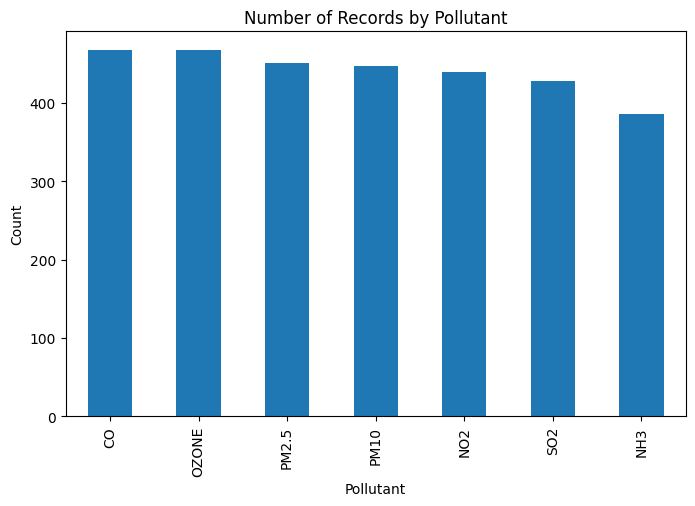

In [10]:
plt.figure(figsize=(8,5))

df['pollutant_id'].value_counts().plot(kind='bar')

plt.title("Number of Records by Pollutant")
plt.xlabel("Pollutant")
plt.ylabel("Count")

plt.show()

## City-wise Air Quality Analysis

In [11]:
city_pollution = (
    df.groupby('city')['pollutant_avg']
      .mean()
      .sort_values(ascending=False)
)

city_pollution.head(10)

city
Byrnihat       99.600000
Khora          86.571429
Dhanbad        84.500000
Noida          81.653846
Singrauli      79.500000
Chittorgarh    78.500000
Pithampur      78.000000
Barmer         73.714286
Jaisalmer      73.142857
Jodhpur        71.800000
Name: pollutant_avg, dtype: float64

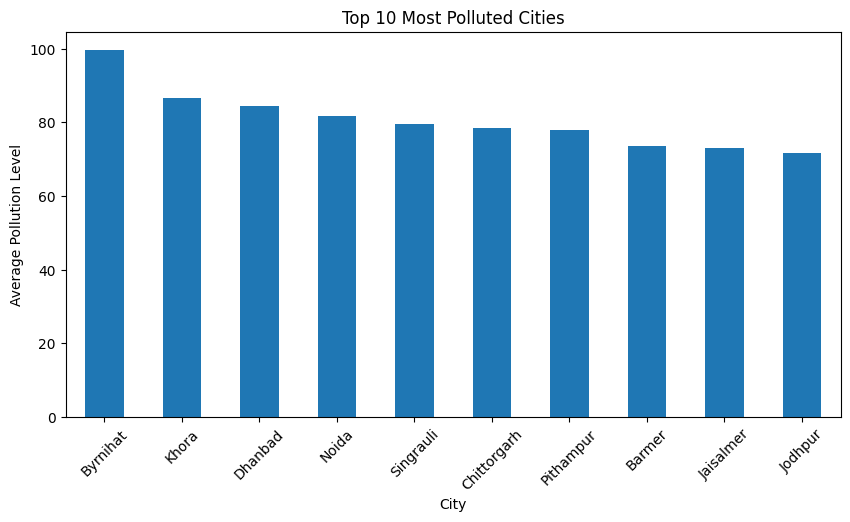

In [12]:
plt.figure(figsize=(10,5))

city_pollution.head(10).plot(kind='bar')

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average Pollution Level")

plt.xticks(rotation=45)

plt.show()

In [13]:
print("Number of Cities:", df['city'].nunique())
print("Number of States:", df['state'].nunique())

Number of Cities: 263
Number of States: 29


In [14]:
city_pollution = (
    df.groupby('city')['pollutant_avg']
      .mean()
      .sort_values(ascending=False)
)

city_pollution.head(10)

city
Byrnihat       99.600000
Khora          86.571429
Dhanbad        84.500000
Noida          81.653846
Singrauli      79.500000
Chittorgarh    78.500000
Pithampur      78.000000
Barmer         73.714286
Jaisalmer      73.142857
Jodhpur        71.800000
Name: pollutant_avg, dtype: float64

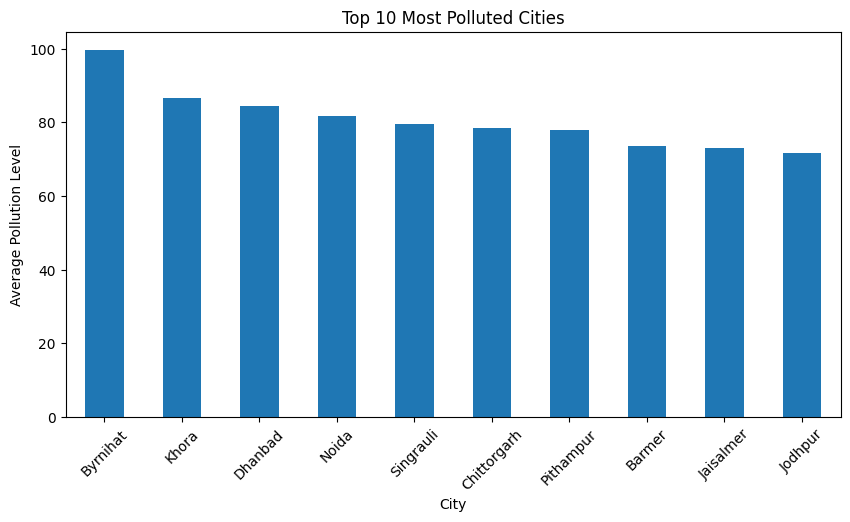

In [15]:
plt.figure(figsize=(10,5))

city_pollution.head(10).plot(kind='bar')

plt.title("Top 10 Most Polluted Cities")
plt.xlabel("City")
plt.ylabel("Average Pollution Level")

plt.xticks(rotation=45)

plt.show()

## Natural Language Query Engine

In [16]:
def answer_question(question):

    q = question.lower()

    # Highest pollution city
    if "highest pollution" in q or "most polluted city" in q:
        
        city = city_pollution.idxmax()
        value = city_pollution.max()

        return f"The most polluted city is {city} with an average pollution level of {value:.2f}"

    # Lowest pollution city
    elif "lowest pollution" in q or "least polluted city" in q:

        city = city_pollution.idxmin()
        value = city_pollution.min()

        return f"The least polluted city is {city} with an average pollution level of {value:.2f}"

    # Top 10 cities
    elif "top 10 polluted cities" in q:

        return city_pollution.head(10)

    else:

        return "Sorry, I cannot answer this question using the available dataset."

In [17]:
print(answer_question("Which city has highest pollution?"))

The most polluted city is Byrnihat with an average pollution level of 99.60


In [18]:
print(answer_question("Which city has lowest pollution?"))

The least polluted city is Cuddalore with an average pollution level of 2.00


In [19]:
print(answer_question("What is the crime rate in Delhi?"))

Sorry, I cannot answer this question using the available dataset.


In [21]:
import gradio as gr

interface = gr.Interface(
    fn=answer_question,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Example: Which city has highest pollution?"
    ),
    outputs="text",
    title="Government Data Analyst",
    description="""
    Ask questions about Indian Air Quality data.

    Supported questions:
    • Which city has highest pollution?
    • Which city has lowest pollution?
    • Show top 10 polluted cities
    """
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


# Conclusion

This project analyzed Indian Air Quality data using government open datasets.

Key findings:

- Byrnihat was identified as the most polluted city in the dataset.
- Cuddalore showed the lowest average pollution level.
- Multiple pollutants such as PM2.5, PM10, NO2, SO2, CO, NH3, and OZONE were analyzed.
- A Natural Language Query Engine was developed to answer user questions using dataset insights.
- A Gradio-based interface was created to provide an interactive user experience.

This solution demonstrates data cleaning, exploratory data analysis, visualization, and interactive analytics using Python.